## Import scGPT and dependencies

In [1]:
from pathlib import Path
import numpy as np
from scipy.stats import mode
import scanpy as sc
import warnings 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns 
import pandas as pd
import sys  

In [2]:
!pip install faiss-cpu

In [3]:
!pip install scanpy 

In [4]:
# extra dependency for similarity search
try:
    import faiss 

    faiss_imported = True
except ImportError:
    faiss_imported = False
    print(
        "faiss not installed! We highly recommend installing it for fast similarity search."
    )
    print("To install it, see https://github.com/facebookresearch/faiss/wiki/Installing-Faiss")

warnings.filterwarnings("ignore", category=ResourceWarning)

In [5]:
print(faiss_imported)

True


In [6]:
import scgpt as scg     

/opt/miniconda3/envs/scgpt/lib/python3.9/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/opt/miniconda3/envs/scgpt/lib/python3.9/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/opt/miniconda3/envs/scgpt/lib/python3.9/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/opt/miniconda3/envs/scgpt/lib/python3.9/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this

In [18]:
model_dir = Path("model/")
adata = sc.read_h5ad('data/sample_proc_lung_train.h5ad')
test_adata = sc.read_h5ad('data/sample_proc_lung_test.h5ad') 



In [8]:
adata.obs


,sample,source,cell_type,subclone,complexity
cell_name,,,,,
AAACCTGAGACGACGT_LUNG_T34,P0034,tLung,B_cell,0,1287
AAACCTGAGACTGTAA_LUNG_T34,P0034,tLung,Malignant,1,5804
AAACCTGAGCCAGGAT_EBUS_28,P1028,tL/B,Malignant,1,1728
AAACCTGAGCTAAACA_LUNG_T34,P0034,tLung,Malignant,1,2530
AAACCTGAGCTAGGCA_EBUS_28,P1028,tL/B,Malignant,1,3414
...,...,...,...,...,...
TTTGTCATCCTGCAGG_LUNG_T34,P0034,tLung,Macrophage,0,2227
TTTGTCATCCTTTCTC_LUNG_T06,P0006,tLung,T_cell,0,1869
TTTGTCATCGACGGAA_LUNG_T25,P0025,tLung,B_cell,0,1911


In [11]:
test_adata.obs

,sample,source,cell_type,subclone,complexity
cell_name,,,,,
AAACCTGAGATGTCGG_LUNG_T31,P0031,tLung,Epithelial,0,1162
AAACCTGAGCGCTTAT_LUNG_T19,P0019,tLung,Macrophage,0,1509
AAACCTGAGGCCCTTG_EBUS_49,P1049,tL/B,T_cell,0,1534
AAACCTGAGGTAAACT_EBUS_49,P1049,tL/B,NK_cell,0,1233
AAACCTGCAACTGCGC_LUNG_T31,P0031,tLung,Epithelial,0,1741
...,...,...,...,...,...
TTTGTCATCAGCATGT_LUNG_T19,P0019,tLung,Macrophage,0,2345
TTTGTCATCCACGTGG_EBUS_06,P1006,tL/B,Malignant,1,1275
TTTGTCATCCTCGCAT_LUNG_T19,P0019,tLung,B_cell,0,1513


In [7]:
cell_type_key = "cell_type"
gene_col = "gene_name"

## 2. Embed the reference dataset


In [14]:
ref_embed_adata = scg.tasks.embed_data(
    adata,
    model_dir,
    gene_col=gene_col,
    batch_size=256, 
)

scGPT - INFO - match 2978/3000 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 91/91 [2:50:30<00:00, 112.43s/it]  
/opt/miniconda3/envs/scgpt/lib/python3.9/site-packages/scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


In [15]:
ref_embed_adata.write_h5ad("data/ref_embed_adata.h5ad")

## 3.Embed the query dataset

In [16]:
test_embed_adata = scg.tasks.embed_data(
    test_adata,
    model_dir, 
    gene_col=gene_col,
    batch_size=256,
)

scGPT - INFO - match 2978/3000 genes in vocabulary of size 60697.


/opt/miniconda3/envs/scgpt/lib/python3.9/site-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
/opt/miniconda3/envs/scgpt/lib/python3.9/site-packages/torch/amp/autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Embedding cells: 100%|██████████| 29/29 [56:42<00:00, 117.31s/it]
/opt/miniconda3/envs/scgpt/lib/python3.9/site-packages/scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


In [17]:
test_embed_adata.write_h5ad("data/test_embed_adata.h5ad")

In [8]:
ref_embed_adata = sc.read_h5ad('data/ref_embed_adata.h5ad')
test_embed_adata = sc.read_h5ad('data/test_embed_adata.h5ad') 

## 4. Concatenate the two datasets

In [ ]:
adata_concat = test_embed_adata.concatenate(ref_embed_adata, batch_key="dataset")
# mark the reference vs. query dataset
adata_concat.obs["is_ref"] = ["Query"] * len(test_embed_adata) + ["Reference"] * len(
    ref_embed_adata
)
adata_concat.obs["is_ref"] = adata_concat.obs["is_ref"].astype("category") 

/var/folders/2c/t0zd8jb93fz3r8h83rjzrppw0000gp/T/ipykernel_7505/2384610660.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_concat = test_embed_adata.concatenate(ref_embed_adata, batch_key="dataset")


## 5. Mask the query dataset cell types

In [10]:
print(adata_concat.obs.columns.tolist())

['sample', 'source', 'cell_type', 'subclone', 'complexity', 'dataset', 'is_ref']


In [11]:


adata_concat.obs[cell_type_key] = adata_concat.obs[cell_type_key].astype("category")
adata_concat.obs[cell_type_key] = adata_concat.obs[cell_type_key].cat.add_categories(["To be predicted"])
adata_concat.obs.loc[
    adata_concat.obs.index[: len(test_embed_adata)], cell_type_key
] = "To be predicted"

## 6. Visualize the embeddings

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


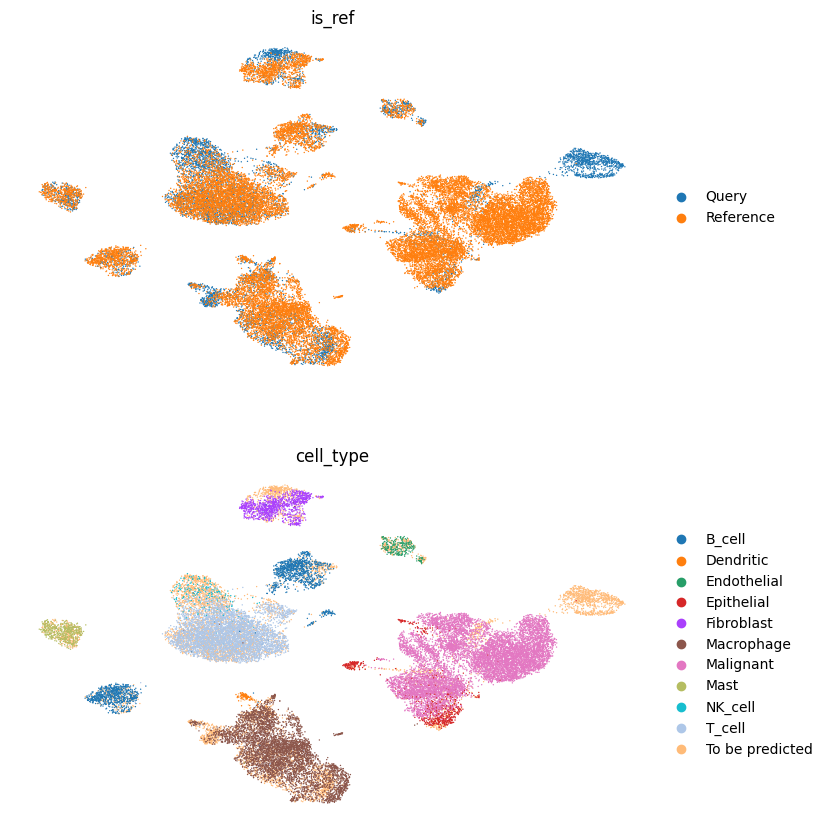

In [12]:
sc.pp.neighbors(adata_concat, use_rep="X_scGPT")
sc.tl.umap(adata_concat)
sc.pl.umap(
    adata_concat, color=["is_ref", cell_type_key], wspace=0.4, frameon=False, ncols=1
)


## 7. Reference mapping and transfer the annotations

In [19]:
from sklearn.neighbors import NearestNeighbors
from collections import Counter

ref_cell_embeddings = ref_embed_adata.obsm["X_scGPT"]
test_embed = test_embed_adata.obsm["X_scGPT"]

knn = NearestNeighbors(
    n_neighbors=10,
    metric="euclidean",
    algorithm="auto",
    n_jobs=-1
)

knn.fit(ref_cell_embeddings)

distances, labels = knn.kneighbors(test_embed)

ref_celltypes = ref_embed_adata.obs[cell_type_key].to_numpy()

preds = [
    Counter(ref_celltypes[idx]).most_common(1)[0][0]
    for idx in labels
]

gt = test_adata.obs[cell_type_key].to_numpy()

## 8. Evaluation of Performance

In [20]:
res_dict = {
    "accuracy": accuracy_score(gt, preds),
    "precision": precision_score(gt, preds, average="macro"),
    "recall": recall_score(gt, preds, average="macro"),
    "macro_f1": f1_score(gt, preds, average="macro"),
}

res_dict

{'accuracy': 0.969534787978592,
 'precision': 0.9673222375410271,
 'recall': 0.9409128970776081,
 'macro_f1': 0.9520103960852871}

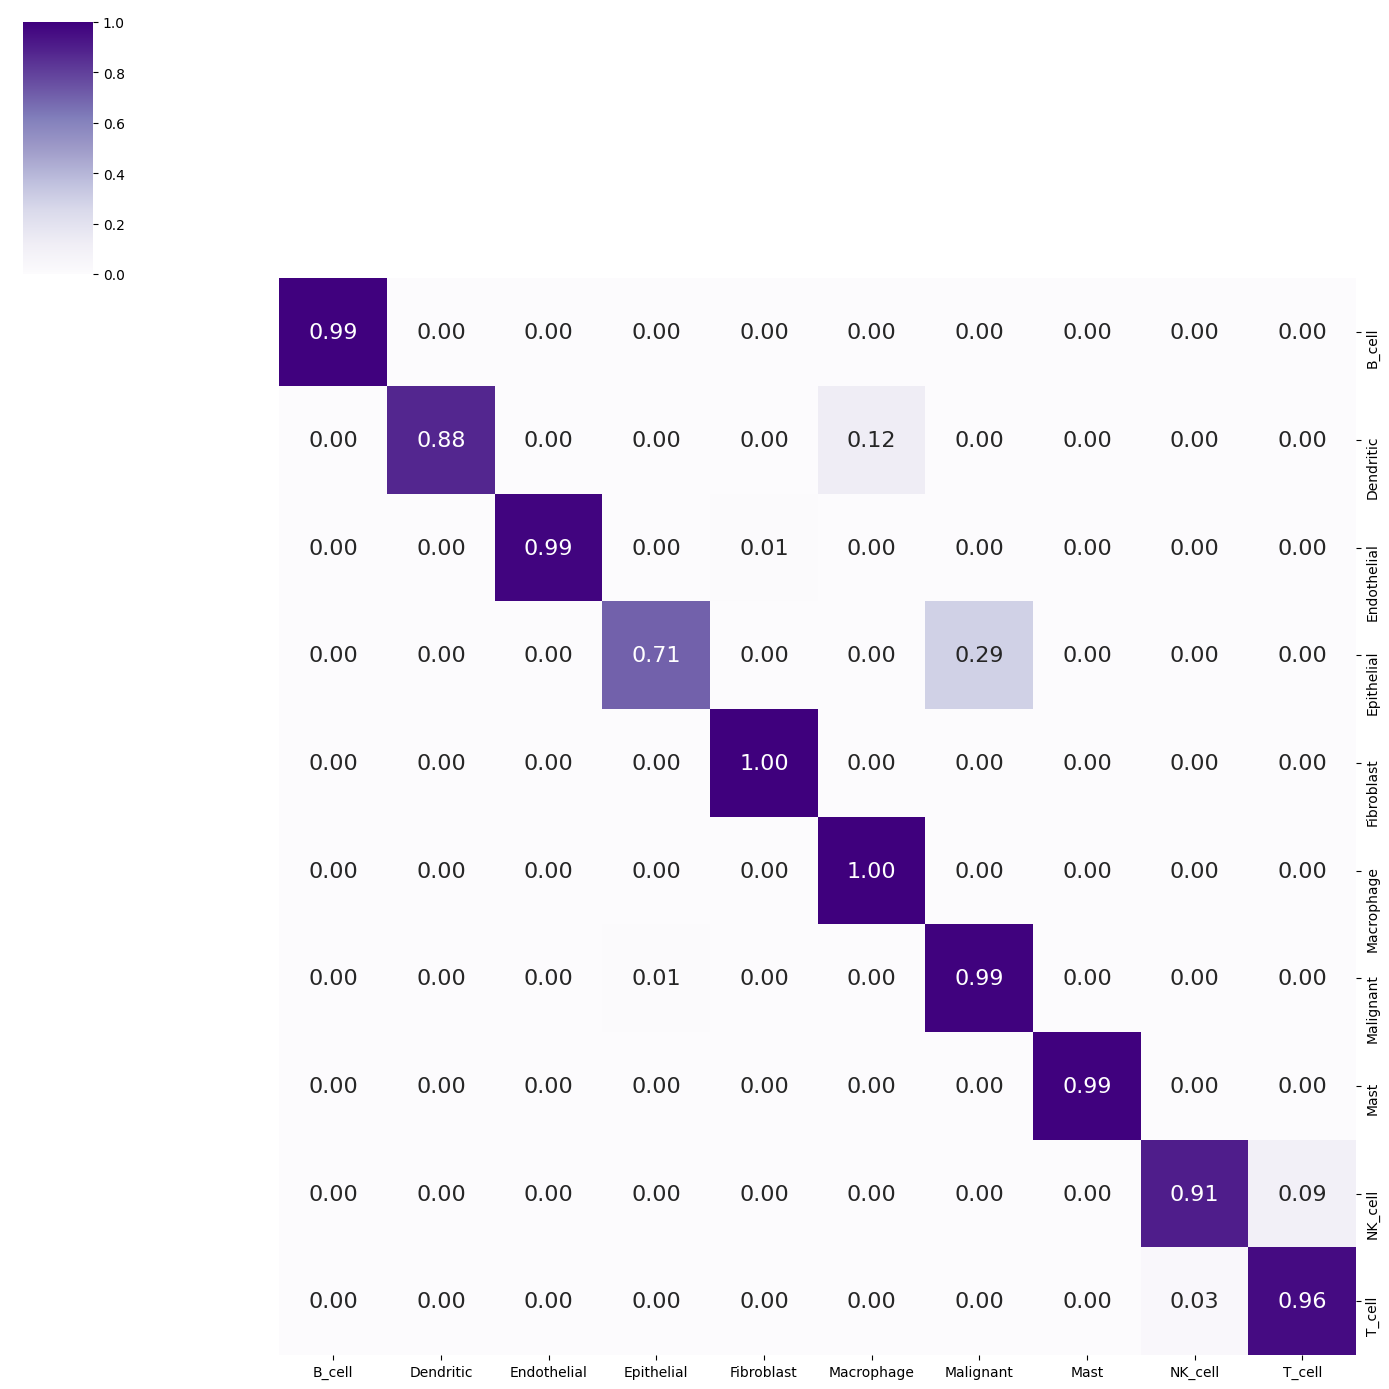

In [21]:
y_true = gt
y_pred = preds
cell_type_list = np.unique(y_true)
matrix = confusion_matrix(y_true, y_pred, labels=cell_type_list)
matrix = matrix.astype("float") / matrix.sum(axis=1)[:, np.newaxis]

df = pd.DataFrame(matrix, index=cell_type_list[:matrix.shape[0]], columns=cell_type_list[:matrix.shape[1]])

ax = sns.clustermap(df,  
                    cmap='Purples',
                    annot=True ,
                    fmt=".2f", 
                    annot_kws={'size': 16}, 
                    vmin=0, 
                    vmax=1,
                    row_cluster=False, 
                    col_cluster=False, 
                    figsize=(14, 14))